In [3]:
import torch
import pennylane as qml


train_size = 300
test_size = 100
epochs = 200
batch_size = 32
hidden_channels = 64
graphlet_size = 3
num_ent_layers = 2
num_gnn_layers = 2
seed = 1712
lr = 0.001
step_size = 10
gamma = 0.3
num_nodes = 20
power = 1
noise = 10

aux_qubit = 1 
node_qubit = graphlet_size
edge_qubit = node_qubit - 1
n_qubits = node_qubit + edge_qubit


step_plot = epochs // 5 if epochs > 10 else 1
device = torch.device("cpu")
q_dev = qml.device("default.qubit", wires=n_qubits + aux_qubit) # number of ancilla qubits


w_shapes_dict = {
    'inits': (num_ent_layers, 4), 
    'strong': (num_ent_layers, 4), 
    'update': (edge_qubit, num_ent_layers, 2 + aux_qubit, 3), 
}

In [4]:
pre_train_epoch = 0

In [5]:
from torch_geometric.loader import DataLoader
from data import d2dGraphDataset
# Load dataset
var_noise = 1/10**(noise/10)  # Convert dB to linear scale
train_dataset = d2dGraphDataset(num_samples=train_size, num_D2D=num_nodes, p_max=power, n0=var_noise, seed=seed)
test_dataset = d2dGraphDataset(num_samples=test_size, num_D2D=num_nodes, p_max=power, n0=var_noise, seed=seed)

node_input_dim = train_dataset[0].x.shape[1] # [direct, weight]
edge_input_dim = train_dataset[0].edge_attr.shape[1] # [inteference]

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

Generate Data ... (seed = 1712)
Generate Data ... (seed = 1712)


In [6]:
import numpy
data = numpy.load("../../results/d2d/d2d_train/data_20260320-102001_qgnn_3_200_0.001_D2D.npz")
# data = numpy.load("../../results/d2d/d2d_train/data_20250714-161928_qgnn_6_100_0.001_D2D.npz")
pre_train_epoch = data['epoch'].shape[0]
training_sinr = data['train_sinr'].tolist()
testing_sinr = data['test_sinr'].tolist()

In [9]:
from model import QGNN
model_quantum = QGNN(
        q_dev=q_dev,
        w_shapes=w_shapes_dict,
        hidden_dim=hidden_channels,
        node_input_dim=node_input_dim,
        edge_input_dim=edge_input_dim,
        graphlet_size=node_qubit,
        hop_neighbor=num_gnn_layers,
    )

pre_trained_path = "../../results/d2d/model/model_20260320-102001_qgnn_3_200_0.001_D2D.pt"
checkpoint = torch.load(pre_trained_path, map_location='cpu')
model_quantum.load_state_dict(checkpoint['model_state_dict'])



<All keys matched successfully>

# Training classical GNN

In [27]:
from baseline import IGCNet
import torch
from torch import nn, optim


training_sinr_gnn = []
testing_sinr_gnn = []
base_model = IGCNet(
    node_input_dim=node_input_dim,
    edge_input_dim=edge_input_dim,
    hidden_channels=hidden_channels,
    num_layers=2
)

base_optimizer = optim.Adam(base_model.parameters(), lr=lr)
base_scheduler = torch.optim.lr_scheduler.StepLR(base_optimizer, step_size=step_size, gamma=0.5)

In [28]:
from utils import train, test
for epoch in range(epochs):
    _, train_gnn = train(base_model, train_loader, base_optimizer, var_noise, power)
    test_gnn = test(base_model, test_loader, var_noise, power)
    training_sinr_gnn.append(train_gnn)
    testing_sinr_gnn.append(test_gnn)
    base_scheduler.step()
    if epoch % step_plot == 0:
        print(f"Epoch {epoch + 1}/{epochs}, Training SINR: {training_sinr_gnn[-1]:.4f}, Testing SINR: {testing_sinr_gnn[-1]:.4f}")


Epoch 1/200, Training SINR: 1.1749, Testing SINR: 0.7359
Epoch 41/200, Training SINR: 3.8771, Testing SINR: 3.5710
Epoch 81/200, Training SINR: 3.9018, Testing SINR: 3.5744
Epoch 121/200, Training SINR: 3.9006, Testing SINR: 3.5729
Epoch 161/200, Training SINR: 3.9037, Testing SINR: 3.5746


# WMMSE

In [29]:
import numpy
total_wmmse = 0
# total_fp = 0
num_batch = 0
for data in train_loader:
    total_wmmse += numpy.sum(data.y[:,0].detach().numpy())
    # total_fp += numpy.sum(data.y[:,1].detach().numpy())
    num_batch += data.num_graphs
train_wmmse = total_wmmse/num_batch
# train_fp = total_fp/num_batch

total_wmmse = 0
# total_fp = 0
num_batch = 0
for data in test_loader:
    total_wmmse += numpy.sum(data.y[:,0].detach().numpy())
    # total_fp += numpy.sum(data.y[:,1].detach().numpy())
    num_batch += data.num_graphs
test_wmmse = total_wmmse/num_batch

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def moving_avg(y, k=5):
    """Simple centred moving average of width k (k should be odd)."""
    pad = k // 2
    y_padded = np.pad(y, (pad, pad), mode="edge")
    return np.convolve(y_padded, np.ones(k)/k, mode="valid")
    # return np.array(y)
k = 11
smooth_train = moving_avg(training_sinr, k=k)   # k=7‑point window
smooth_test  = moving_avg(testing_sinr,  k=k)

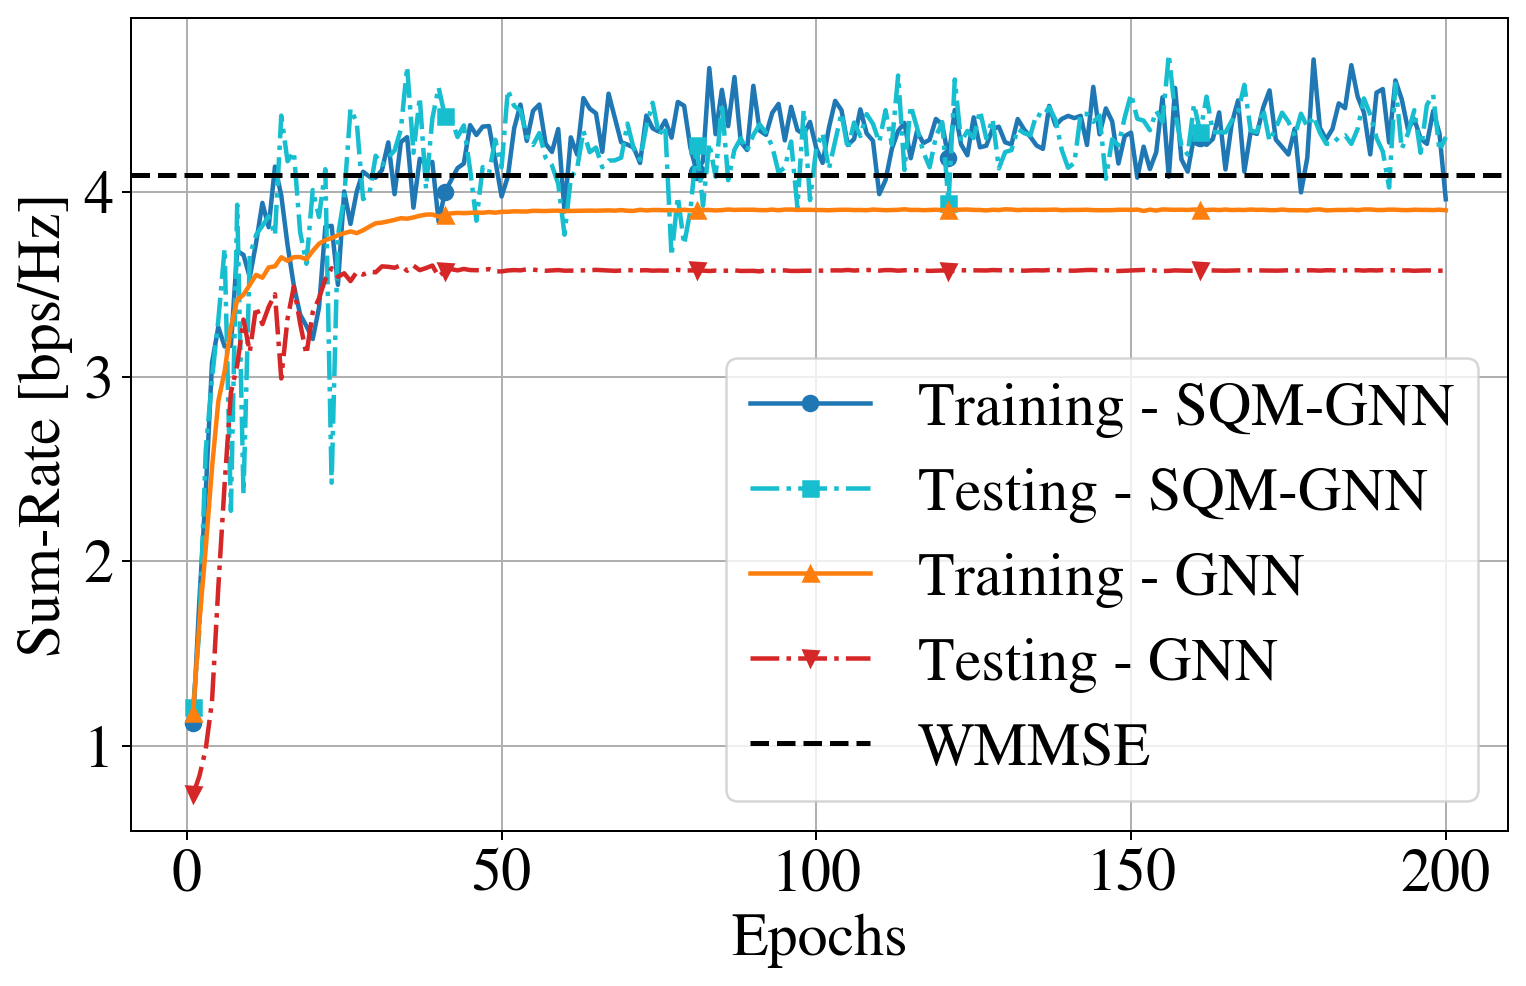

In [31]:
import matplotlib.pyplot as plt
import numpy

plt.rc("text", usetex=False)
plt.rcParams['mathtext.fontset'] = 'cm'
plt.rcParams['font.family'] = 'STIXGeneral'
plt.rcParams.update({'font.size': 24})
fig, ax = plt.subplots(figsize=(9, 6), dpi=180)

# QGNN
plt.plot(range(1, epochs+1), smooth_train,
# plt.plot(range(1, epochs + 1), training_sinr,
        label=f'Training - SQM-GNN', markevery=step_plot,

        marker='o', linewidth=1.8, color='tab:blue')

plt.plot(range(1, epochs+1), smooth_test,
# plt.plot(range(1, epochs + 1), testing_sinr,
        label=f'Testing - SQM-GNN', markevery=step_plot, linestyle='-.',
        marker='s', linewidth=1.8, color='tab:cyan')


plt.plot(range(1, epochs + 1), numpy.array(training_sinr_gnn),
        label=f'Training - GNN', markevery=step_plot,
        marker='^', linewidth=1.8, color='tab:orange')

plt.plot(range(1, epochs + 1), numpy.array(testing_sinr_gnn),
        label=f'Testing - GNN', markevery=step_plot, linestyle='-.',
        marker='v', linewidth=1.8, color='tab:red')

# WMMSE baseline
plt.axhline(y=test_wmmse, color='k', linestyle='--', linewidth=2,
            label='WMMSE')

# plt.title('Unsupervised Setting')
plt.xlabel('Epochs')
plt.ylabel('Sum-Rate [bps/Hz]')
# plt.xticks(range(1,total_epoch+1))
plt.legend()
plt.grid(True)

plt.tight_layout()
# plt.savefig("../../results/D2D_Res.pdf", format="pdf", bbox_inches="tight")
plt.savefig("./D2D_Res.pdf", format="pdf", bbox_inches="tight")

# Evaluation

In [9]:
eval_size = 1000
eval_seed = 1309
all_scenarios = [
    (4, 1),
    (5, 1),
    (6, 1),
    (7, 1),
    (10, 1),
    (20, 1),
    (30, 1),
    (40, 1),
]

In [26]:
for num_nodes, power in all_scenarios:
    print(f'{num_nodes, power}')
    # Create new evaluation dataset and loader
    eval_dataset = d2dGraphDataset(
        num_samples=eval_size,  # e.g., 500 or 1000
        num_D2D=num_nodes,
        p_max=power,
        n0=var_noise,
        seed=eval_seed  # optional, for reproducibility
    )
    eval_loader = DataLoader(eval_dataset, batch_size=batch_size, shuffle=False)

    # Evaluate
    eval_sinr = test(base_model, eval_loader, var_noise, power)
    eval_sinr_quantum = test(model_quantum, eval_loader, var_noise, power)
    print(f"GNN SINR: {eval_sinr:.4f}")
    print(f"SQM-GNN SINR: {eval_sinr_quantum:.4f}")


(4, 1)
Generate Data ... (seed = 1309)
GNN SINR: 1.8792
SQM-GNN SINR: 0.3345
(5, 1)
Generate Data ... (seed = 1309)
GNN SINR: 2.1787
SQM-GNN SINR: 0.9048
(6, 1)
Generate Data ... (seed = 1309)
GNN SINR: 2.2573
SQM-GNN SINR: 2.4576
(7, 1)
Generate Data ... (seed = 1309)


KeyboardInterrupt: 

In [ ]:
total_wmmse = 0
# total_fp = 0
num_batch = 0
for data in test_loader:
    total_wmmse += numpy.sum(data.y[:,0].detach().numpy())
    # total_fp += numpy.sum(data.y[:,1].detach().numpy())
    num_batch += data.num_graphs
test_wmmse = total_wmmse/num_batch
# test_fp = total_fp/num_batch

gnn_train_size = train_size
train_dataset = d2dGraphDataset(num_samples=gnn_train_size, num_D2D=num_nodes, p_max=power, n0=var_noise, seed=seed)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
# main baseline model
training_sinr_gnn = []
testing_sinr_gnn = []
base_model = IGCNet(
    node_input_dim=node_input_dim,
    edge_input_dim=edge_input_dim,
    hidden_channels=hidden_channels,
    num_layers=num_gnn_layers
)   
base_optimizer = optim.Adam(base_model.parameters(), lr=lr)
base_scheduler = torch.optim.lr_scheduler.StepLR(base_optimizer, step_size=step_size, gamma=gamma)
print("training baseline GNN:...")
total_epoch = epochs + pre_train_epoch
for epoch in range(total_epoch):
    _, train_gnn = train(base_model, train_loader, base_optimizer, var_noise, power)
    test_gnn = test(base_model, test_loader, var_noise, power)
    training_sinr_gnn.append(train_gnn)
    testing_sinr_gnn.append(test_gnn)
    base_scheduler.step()
    
plt.rcParams.update({'font.size': 14})

plt.figure(figsize=(10, 6))
# QGNN

training_sinr = smooth(training_sinr, weight=0.85)
testing_sinr = smooth(testing_sinr, weight=0.85)
training_sinr_gnn = smooth(training_sinr_gnn, weight=0.85)
testing_sinr_gnn = smooth(testing_sinr_gnn, weight=0.85)

plt.plot(range(1, total_epoch + 1), training_sinr,
        label=f'Training Sum-Rate - QGNN', markevery=step_plot,
        marker='o', linewidth=1.8, color='tab:blue')

plt.plot(range(1, total_epoch + 1), testing_sinr,
        label=f'Testing  Sum-Rate - QGNN', markevery=step_plot,
        marker='s', linewidth=1.8, color='tab:cyan')

# Classical GNN
plt.plot(range(1, total_epoch + 1), training_sinr_gnn,
        label=f'Training Sum-Rate - GNN', markevery=step_plot,
        marker='^', linewidth=1.8, color='tab:orange')

plt.plot(range(1, total_epoch + 1), testing_sinr_gnn,
        label=f'Testing  Sum-Rate - GNN', markevery=step_plot,
        marker='v', linewidth=1.8, color='tab:red')

# WMMSE baseline
plt.axhline(y=test_wmmse, color='k', linestyle='--', linewidth=2,
            label='WMMSE (baseline)')

plt.title('Unsupervised Setting')
plt.xlabel('Epoch')
plt.ylabel('SINR')
# plt.xticks(range(1,total_epoch+1))
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(plot_train_path, dpi=300)

In [ ]:
def smooth(values, weight=0.9):  # weight closer to 1 = smoother
    smoothed = []
    last = values[0]
    for v in values:
        last = last * weight + v * (1 - weight)
        smoothed.append(last)
    return smoothed

In [1]:
import numpy
data = numpy.load("../../results/d2d/d2d_train/data_20260319-163602_qgnn_3_100_0.001_D2D.npz")
# data = numpy.load("../../results/d2d/d2d_train/data_20250714-161928_qgnn_6_100_0.001_D2D.npz")
pre_train_epoch = data['epoch'].shape[0]
training_sinr = data['train_sinr'].tolist()
testing_sinr = data['test_sinr'].tolist()

In [2]:
from model import QGNN
model_quantum = QGNN(
        q_dev=q_dev,
        w_shapes=w_shapes_dict,
        hidden_dim=hidden_channels,
        node_input_dim=node_input_dim,
        edge_input_dim=edge_input_dim,
        graphlet_size=node_qubit,
        hop_neighbor=num_gnn_layers,
    )

pre_trained_path = "../../results/d2d/model/model_20250714-161928_qgnn_6_100_0.001_D2D.pt"
checkpoint = torch.load(pre_trained_path, map_location='cpu')
model_quantum.load_state_dict(checkpoint['model_state_dict'])



NameError: name 'q_dev' is not defined

In [ ]:
file_name = 'data_20260319-163602_qgnn_3_100_0.001_D2D.npz'

In [ ]:
import matplotlib.pyplot as plt
import numpy

plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 14})
# QGNN

training_sinr = smooth(training_sinr, weight=0.85)
testing_sinr = smooth(testing_sinr, weight=0.85)
training_sinr_gnn = smooth(training_sinr_gnn, weight=0.85)
testing_sinr_gnn = smooth(testing_sinr_gnn, weight=0.85)

plt.plot(range(1, total_epoch + 1), training_sinr,
        label=f'Training Sum-Rate - QGNN', markevery=step_plot,
        marker='o', linewidth=1.8, color='tab:blue')

plt.plot(range(1, total_epoch + 1), testing_sinr,
        label=f'Testing  Sum-Rate - QGNN', markevery=step_plot,
        marker='s', linewidth=1.8, color='tab:cyan')

# Classical GNN
plt.plot(range(1, total_epoch + 1), training_sinr_gnn,
        label=f'Training Sum-Rate - GNN', markevery=step_plot,
        marker='^', linewidth=1.8, color='tab:orange')

plt.plot(range(1, total_epoch + 1), testing_sinr_gnn,
        label=f'Testing  Sum-Rate - GNN', markevery=step_plot,
        marker='v', linewidth=1.8, color='tab:red')

# WMMSE baseline
plt.axhline(y=test_wmmse, color='k', linestyle='--', linewidth=2,
            label='WMMSE (baseline)')

plt.title('Unsupervised Setting')
plt.xlabel('Epoch')
plt.ylabel('SINR')
# plt.xticks(range(1,total_epoch+1))
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.savefig(plot_train_path, dpi=300)